<div style="background:linear-gradient(135deg,#042f2e 0%,#0f766e 55%,#14b8a6 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#99f6e4;font-weight:700;text-transform:uppercase">Chapter 37 · Probability Distributions</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Discrete Distributions 🔔</div>
  <div style="font-size:15px;color:#d1fae5;max-width:740px;line-height:1.6">A handful of named distributions describe most counting problems you will ever meet. This notebook builds the binomial, geometric, Poisson, and hypergeometric distributions, checks each mean and variance by simulation, watches the binomial become Poisson, and ends with the Bernoulli likelihood that powers logistic regression.</div>
  <div style="margin-top:16px;font-size:13px;color:#a7f3d0">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
rng = np.random.default_rng(37)
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False})
TEAL="#0d9488"; PINK="#db2777"; AMBER="#d97706"
print("ready")

ready


<div style="background:#ecfdf5;border-left:5px solid #0d9488;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0d9488;letter-spacing:1px">DEMO 1 · BERNOULLI &amp; BINOMIAL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Counting successes in n trials</div>
<div style="color:#4a5578;margin-top:6px">A Bernoulli trial is a single yes/no event with success probability p. A binomial counts the successes in n independent Bernoulli trials. Its mean is np and its variance is np(1-p).</div>
</div>

In [2]:
n, p = 10, 0.3
k = np.arange(0, n+1)
pmf = stats.binom.pmf(k, n, p)
print(f"mean np        = {n*p:.3f}")
print(f"variance np(1-p) = {n*p*(1-p):.3f}")

sim = rng.binomial(n, p, size=200_000)
print(f"simulated mean = {sim.mean():.3f},  simulated var = {sim.var():.3f}")

mean np        = 3.000
variance np(1-p) = 2.100
simulated mean = 2.998,  simulated var = 2.096


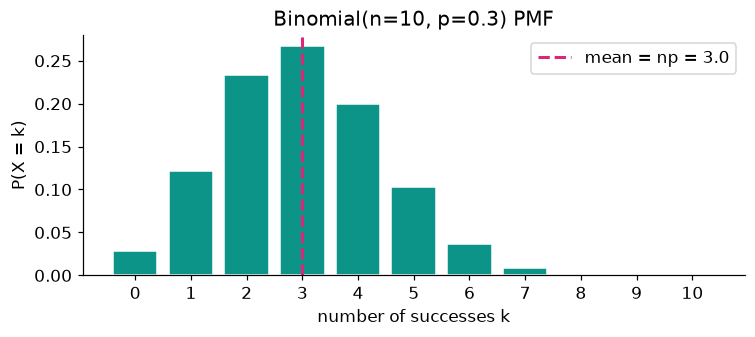

In [3]:
fig,ax=plt.subplots(figsize=(7,3.2))
ax.bar(k, pmf, color=TEAL, edgecolor="white")
ax.axvline(n*p, color=PINK, ls="--", lw=2, label=f"mean = np = {n*p:.1f}")
ax.set_xticks(k); ax.set_xlabel("number of successes k"); ax.set_ylabel("P(X = k)")
ax.set_title(f"Binomial(n={n}, p={p}) PMF"); ax.legend()
plt.tight_layout(); plt.show()

The binomial PMF is C(n, k) p^k (1-p)^(n-k): the number of ways to place k successes, times the probability of each arrangement. With n=10, p=0.3 the distribution centers on np = 3, and the simulated mean and variance match the formulas.

<div style="background:#ecfdf5;border-left:5px solid #0d9488;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0d9488;letter-spacing:1px">DEMO 2 · GEOMETRIC</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">How long until the first success?</div>
<div style="color:#4a5578;margin-top:6px">The geometric distribution counts the number of trials up to and including the first success. Its PMF is (1-p)^(k-1) p, and its mean is 1/p, the average wait.</div>
</div>

In [4]:
p = 0.2
k = np.arange(1, 26)
pmf = stats.geom.pmf(k, p)
print(f"mean 1/p = {1/p:.1f} trials to the first success")
sim = rng.geometric(p, size=200_000)
print(f"simulated mean = {sim.mean():.3f}")

mean 1/p = 5.0 trials to the first success
simulated mean = 5.012


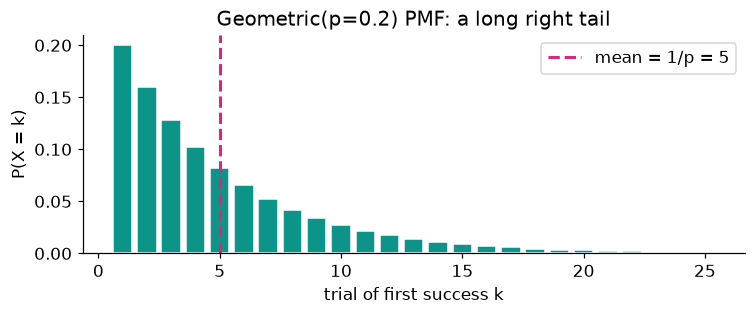

In [5]:
fig,ax=plt.subplots(figsize=(7,3))
ax.bar(k, pmf, color=TEAL, edgecolor="white")
ax.axvline(1/p, color=PINK, ls="--", lw=2, label=f"mean = 1/p = {1/p:.0f}")
ax.set_xlabel("trial of first success k"); ax.set_ylabel("P(X = k)")
ax.set_title(f"Geometric(p={p}) PMF: a long right tail"); ax.legend()
plt.tight_layout(); plt.show()

The geometric distribution is "memoryless" and skewed right: with p = 0.2 the single most likely outcome is success on the *first* try, yet the long tail pulls the average wait up to 1/p = 5 trials. Waiting for a rare event takes longer, on average, than intuition suggests.

<div style="background:#ecfdf5;border-left:5px solid #0d9488;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0d9488;letter-spacing:1px">DEMO 3 · POISSON</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Counts of rare events, and the binomial limit</div>
<div style="color:#4a5578;margin-top:6px">The Poisson distribution counts events in a fixed interval when they happen at a steady average rate lambda. Remarkably, mean = variance = lambda, and it is the limit of a binomial with large n and small p.</div>
</div>

In [6]:
lam = 3.0
k = np.arange(0, 12)
pois = stats.poisson.pmf(k, lam)
print(f"Poisson: mean = variance = lambda = {lam}")

# binomial -> Poisson: large n, small p, with n*p = lambda
n, p = 1000, lam/1000
binom = stats.binom.pmf(k, n, p)
print(f"max |binom(n=1000,p=0.003) - Poisson(3)| = {np.abs(binom-pois).max():.5f}")

Poisson: mean = variance = lambda = 3.0
max |binom(n=1000,p=0.003) - Poisson(3)| = 0.00034


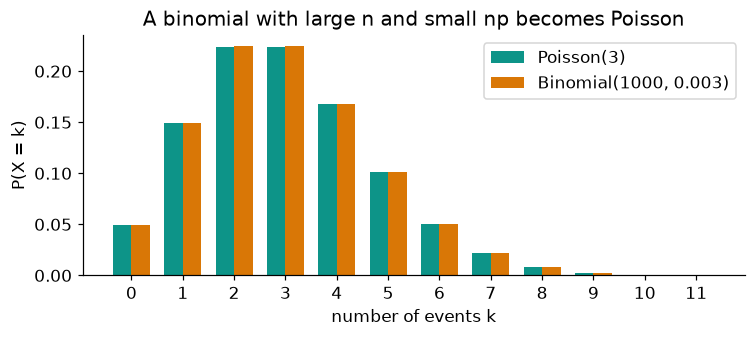

In [7]:
fig,ax=plt.subplots(figsize=(7,3.2))
ax.bar(k-0.18, pois, width=0.36, color=TEAL, label="Poisson(3)")
ax.bar(k+0.18, binom, width=0.36, color=AMBER, label="Binomial(1000, 0.003)")
ax.set_xticks(k); ax.set_xlabel("number of events k"); ax.set_ylabel("P(X = k)")
ax.set_title("A binomial with large n and small np becomes Poisson"); ax.legend()
plt.tight_layout(); plt.show()

The two distributions are nearly identical: when successes are rare but trials are many, the binomial collapses onto the Poisson with lambda = np. This is why the Poisson models call arrivals, typos per page, or website hits per minute, all "many chances, each unlikely".

<div style="background:#ecfdf5;border-left:5px solid #0d9488;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0d9488;letter-spacing:1px">DEMO 4 · HYPERGEOMETRIC</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Sampling without replacement</div>
<div style="color:#4a5578;margin-top:6px">When you draw without replacement, trials are no longer independent and the binomial no longer applies. The hypergeometric distribution handles it: draw N items from a population of M with K 'successes'.</div>
</div>

In [8]:
M, K, N = 50, 5, 10        # 50 items, 5 defective, draw 10 without replacement
k = np.arange(0, 6)
hyper = stats.hypergeom.pmf(k, M, K, N)
binom = stats.binom.pmf(k, N, K/M)    # the with-replacement approximation
print("defects   hypergeometric   binomial(p=0.1)")
for ki,h,b in zip(k,hyper,binom):
    print(f"   {ki}        {h:.4f}          {b:.4f}")
print(f"\nP(exactly 1 defective), no replacement = {hyper[1]:.4f}")

defects   hypergeometric   binomial(p=0.1)
   0        0.3106          0.3487
   1        0.4313          0.3874
   2        0.2098          0.1937
   3        0.0442          0.0574
   4        0.0040          0.0112
   5        0.0001          0.0015

P(exactly 1 defective), no replacement = 0.4313


The hypergeometric (without replacement) and binomial (with replacement) agree roughly but not exactly: removing items changes the odds for the next draw. When the population is large relative to the sample, the difference shrinks and the simpler binomial is a fine approximation.

<div style="background:#ecfdf5;border-left:5px solid #0d9488;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0d9488;letter-spacing:1px">DEMO 5 · THE BERNOULLI LIKELIHOOD</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">How a classifier learns p</div>
<div style="color:#4a5578;margin-top:6px">Logistic regression and every probabilistic classifier rest on the Bernoulli distribution. Given data, the value of p that maximizes the Bernoulli likelihood is exactly the observed success rate.</div>
</div>

In [9]:
true_p = 0.7
data = rng.binomial(1, true_p, size=200)      # 200 Bernoulli trials
k = data.sum()
print(f"observed: {k} successes in 200 -> sample proportion = {k/200:.3f}")

# log-likelihood of p given the data, over a grid
grid = np.linspace(0.01, 0.99, 400)
loglik = k*np.log(grid) + (200-k)*np.log(1-grid)
p_hat = grid[np.argmax(loglik)]
print(f"maximum-likelihood estimate p_hat = {p_hat:.3f}  (matches the proportion)")

observed: 128 successes in 200 -> sample proportion = 0.640
maximum-likelihood estimate p_hat = 0.639  (matches the proportion)


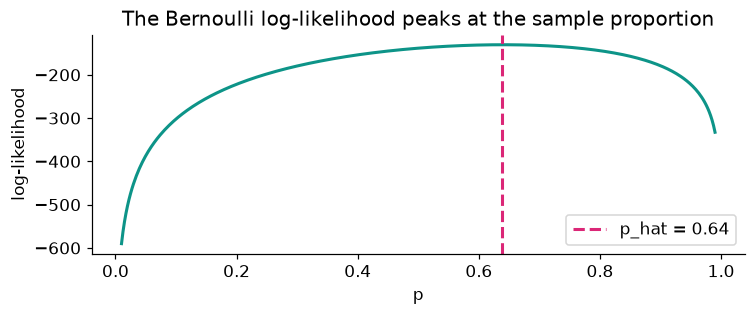

In [10]:
fig,ax=plt.subplots(figsize=(7,3))
ax.plot(grid, loglik, color=TEAL, lw=2)
ax.axvline(p_hat, color=PINK, ls="--", lw=2, label=f"p_hat = {p_hat:.2f}")
ax.set_xlabel("p"); ax.set_ylabel("log-likelihood")
ax.set_title("The Bernoulli log-likelihood peaks at the sample proportion"); ax.legend()
plt.tight_layout(); plt.show()

Maximizing the Bernoulli likelihood is the same as minimizing **cross-entropy loss**, the negative log-likelihood from Chapter 35. A logistic-regression classifier does exactly this: it tunes its parameters so the predicted Bernoulli probability best matches the observed labels. The humble coin-flip distribution is the statistical heart of binary classification.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ What you built</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">You constructed the four workhorse discrete distributions, confirmed their means and variances by simulation, watched a binomial become Poisson, compared drawing with and without replacement, and maximized a Bernoulli likelihood the way a classifier does. Each "named" distribution is just a reusable recipe for a common kind of count.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>